# Projeto de Predição de Preços de Carros — EDA
Este notebook performa uma análise de dados exploratória (EDA) utilizando um dataset de carros usados da CarDekho, buscando identificar padrões, correlações, outliers e fatores que influenciam o preço dos veículos.



---


# Importando o Dataset e as Bibliotecas


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vehicle-dataset-from-cardekho' dataset.
Path to dataset files: /kaggle/input/vehicle-dataset-from-cardekho






# Visão Geral
Nesta seção, é realizada uma exploração inicial do dataset, analisando a estrutura dos dados, quantidade de linhas e colunas, tipos das variáveis e exemplos dos registros.

In [5]:
df = pd.read_csv("/kaggle/input/vehicle-dataset-from-cardekho/CAR DETAILS FROM CAR DEKHO.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


# Missing Values e Duplicates
Aqui são analisados os valores ausentes e duplicados presentes no dataset, identificando possíveis problemas de qualidade nos dados e verificando a necessidade de tratamento.

In [7]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


Não há nulos no dataset.

In [8]:
df.duplicated().sum()

np.int64(763)

Pelo visto há 763 linhas repetidas, vamos checar se as linhas realmente são iguais para poder excluir de forma segura.

In [9]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
3912,Ambassador CLASSIC 1500 DSL AC,2005,120000,50000,Diesel,Individual,Manual,Second Owner
4016,Ambassador CLASSIC 1500 DSL AC,2005,120000,50000,Diesel,Individual,Manual,Second Owner
99,Audi A4 2.0 TDI 177 Bhp Premium Plus,2013,1150000,53000,Diesel,Dealer,Automatic,First Owner
2578,Audi A4 2.0 TDI 177 Bhp Premium Plus,2013,1150000,53000,Diesel,Dealer,Automatic,First Owner
554,Audi A4 3.0 TDI Quattro,2013,1580000,86000,Diesel,Dealer,Automatic,First Owner
...,...,...,...,...,...,...,...,...
2936,Volkswagen Vento 1.5 TDI Highline Plus AT,2017,890000,40219,Diesel,Dealer,Automatic,First Owner
1628,Volkswagen Vento Diesel Comfortline,2012,215000,97000,Diesel,Individual,Manual,First Owner
3052,Volkswagen Vento Diesel Comfortline,2012,215000,97000,Diesel,Individual,Manual,First Owner
478,Volkswagen Vento Diesel Highline,2011,300000,65000,Diesel,Individual,Manual,Second Owner


Realmente são linhas idênticas, então podemos remover.

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(3577, 8)

# Estatísticas Descritivas
Esta etapa apresenta medidas estatísticas das variáveis numéricas, como média, mediana, desvio padrão e quartis, permitindo uma melhor compreensão da distribuição dos dados.

In [12]:
df.describe()

,year,selling_price,km_driven
count,3577.000000,3.577000e+03,3577.000000
mean,2012.962538,4.739125e+05,69250.545709
std,4.251759,5.093018e+05,47579.940016
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,36000.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


## Agrupamentos e Filtragens

In [37]:
df.groupby('transmission').agg(
    quantidade_carros=('transmission', 'size'),
    mediana_preco=('selling_price', 'median')
).sort_values(by='mediana_preco', ascending=False)

,quantidade_carros,mediana_preco
transmission,,
Automatic,312,855000.0
Manual,3265,325000.0


Aqui podemos notar uma diferença discrepante entre carros manuais e automáticos. Enquanto o manual oferece preços menores e mais opções de carros à venda, carros automáticos tendem a ser mais raros de encontrar e com um preço mais elevado. Vamos continuar analisando para descobrir a causa.

In [49]:
df.loc[df['transmission'] == 'Automatic', 'year'].value_counts().sort_index(ascending=False).head()

,count
year,
2020,2
2019,28
2018,52
2017,57
2016,22


Decidi analisar se carros automáticos tinham anos mais recentes, pois geralmente carros mais novos tendem a ser mais caros. Porém, isso ainda não respondeu a pergunta, vamos tentar ver se o tipo de dono influencia no preço e se a quilometragem de carros automáticos é mais baixa.

In [58]:
df.groupby('transmission')['km_driven'].median().sort_values(ascending=False)

,km_driven
transmission,
Manual,64484.0
Automatic,46478.5


Ao analisar a primeira tabela, vemos que a maior parte dos donos dos carros automáticos são os primeiros donos do veículo. E na tabela seguinte, percebemos que a quilometragem dos automáticos é menor do que de carros manuais. Contudo, ainda não é o suficiente para afirmarmos algo com certeza. Vamos tentar descobrir se os carros automáticos têm preços geralmente maiores, ou se os automáticos anunciados coincidentemente são de marcas "premium".

In [29]:
df.groupby('owner')[['selling_price', 'km_driven']].median().sort_values(by='selling_price', ascending=False)

,selling_price,km_driven
owner,,
Test Drive Car,894999.0,1010.0
First Owner,450000.0,50000.0
Second Owner,267000.0,80000.0
Third Owner,190000.0,90000.0
Fourth & Above Owner,138000.0,97000.0


Vemos que cada preço é respectivamente referente à quilometragem e ao tipo de dono, e podemos perceber também que carros de test drive são mais caros por conta da quilometragem baixíssima que eles apresentam.

In [60]:
df.groupby('seller_type')[['selling_price', 'km_driven']].median().sort_values(by='selling_price', ascending=False)

,selling_price,km_driven
seller_type,,
Trustmark Dealer,750000.0,47162.0
Dealer,484999.0,52000.0
Individual,303500.0,70000.0


Carros vendidos por revendedores confiáveis são mais caros pois a quilometragem dos seus veículos é mais baixa. Além de que podem oferecer garantia, documentação correta e menor risco de golpe.

In [61]:
df.groupby('fuel')[['selling_price','km_driven']].median().sort_values(by='selling_price', ascending=False)

,selling_price,km_driven
fuel,,
Diesel,475000.0,80000.0
Electric,310000.0,62000.0
Petrol,260000.0,50000.0
CNG,229999.0,71000.0
LPG,180000.0,90000.0


Veículos a diesel tendem a apresentar alta quilometragem em comparação aos movidos a gasolina, pois como são mais utilizados em viagens longas acabam acumulando mais KM, porém continuam com preços mais altos.

# Checando a Distribuição dos Dados

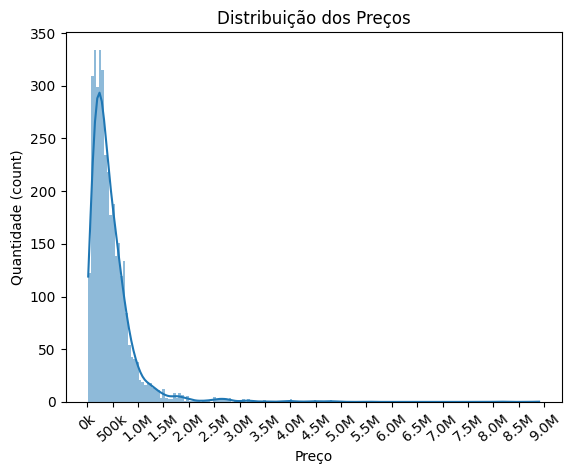

In [14]:
from matplotlib.ticker import FuncFormatter, MultipleLocator

sns.histplot(df['selling_price'], kde=True, stat='count', linewidth=0)
plt.xlabel('Preço')
plt.ylabel('Quantidade (count)')
plt.title('Distribuição dos Preços')

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(500000))

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f'{x/1_000_000:.1f}M'
        if x >= 1_000_000
        else f'{int(x/1000)}k' #para a simplicidade da visualização, formatei em mil e milhões ao invés de usar a escala 1e6
    )
)

plt.xticks(rotation=40)

plt.show()

Podemos perceber que a maior parte dos preços dos veículos usados está concentrada abaixo de 2 milhões, indicando uma distribuição assimétrica à direita. O histograma revela uma alta concentração de veículos em faixas de preço menores, enquanto poucos carros possuem valores extremamente elevados. Além disso, o pico do gráfico mostra maior frequência de veículos próximos da faixa de 500 mil, com mais de 300 ocorrências.

# Outliers
Aqui são identificados possíveis outliers presentes nas variáveis numéricas utilizando boxplots, possibilitando observar valores extremos e compreender melhor a dispersão dos dados.

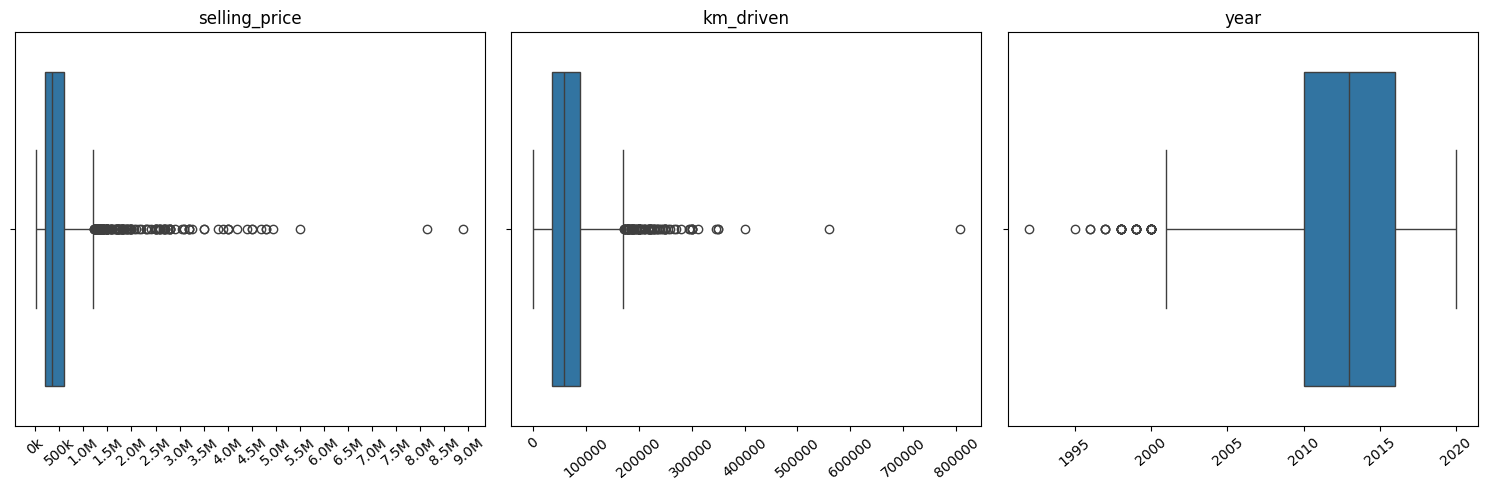

In [15]:
num_cols = ['selling_price', 'km_driven', 'year']

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=40)
    axes[i].set_xlabel('')

axes[0].xaxis.set_major_locator(MultipleLocator(500000))

axes[0].xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f'{x/1_000_000:.1f}M'
        if x >= 1_000_000
        else f'{int(x/1000)}k'
    )
)

plt.tight_layout()
plt.show()

Vamos analisar cada gráfico:

O primeiro gráfico (*selling_price*) é referente aos preços dos carros usados, e podemos notar que a maior parte dos preços dos veículos está concentrada entre 200 mil e 600 mil (valores previamente vistos no 'df.describe' logo acima), com uma mediana de 350 mil dólares.
O boxplot também apresenta diversos outliers acima do limite superior do whisker, indicando veículos com preços muito acima da maioria. Isso sugere alta variabilidade nos valores, o que faz sentido já que o dataset contém desde carros populares até veículos de luxo e esportivos.


Agora o segundo gráfico (*km_driven*), é notável que a maior parte dos veículos apresenta quilometragem moderada, com mediana próxima de 60 mil km. Também é possível observar diversos outliers acima do whisker superior, sugerindo a existência de carros muito mais rodados que o restante da amostra.


E no último gráfico, (*year*), é perceptível que a distribuição dos anos dos veículos está concentrada entre 2013 e 2016, sugerindo predominância de carros relativamente novos no dataset. O gráfico também evidencia alguns outliers inferiores, indicando a presença de veículos significativamente mais antigos em comparação com a maior parte da amostra.



# Correlação e Relação entre Váriaveis
Nesta seção, é analisada a correlação entre as variáveis numéricas do dataset, permitindo identificar relações positivas, negativas e a intensidade dessas relações, além de gráficos de dispersão para visualizar a relação entre variáveis importantes do dataset, auxiliando na identificação de tendências, padrões e dispersão dos dados.

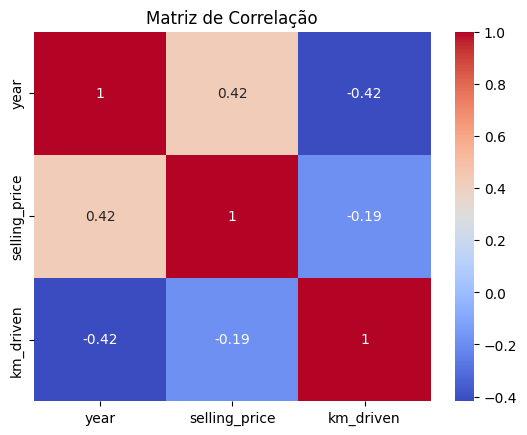

In [16]:
num_cols = df.select_dtypes(include='number')
corr_matrix = num_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

Observa-se uma forte correlação positiva entre as variáveis *year* e *selling_price*, indicando que veículos mais novos tendem a apresentar preços mais altos.
Também é possível identificar uma forte correlação negativa entre *year* e *km_driven*, sugerindo que carros mais recentes geralmente possuem menor quilometragem.
Já a relação entre *km_driven* e *selling_price* é mais fraca, indicando que a quilometragem isoladamente não explica tão bem o preço de venda.

Além da matriz de correlação, foi construído um scatterplot para melhor visualizar a dispersão dos dados, identificar tendências e possíveis outliers.

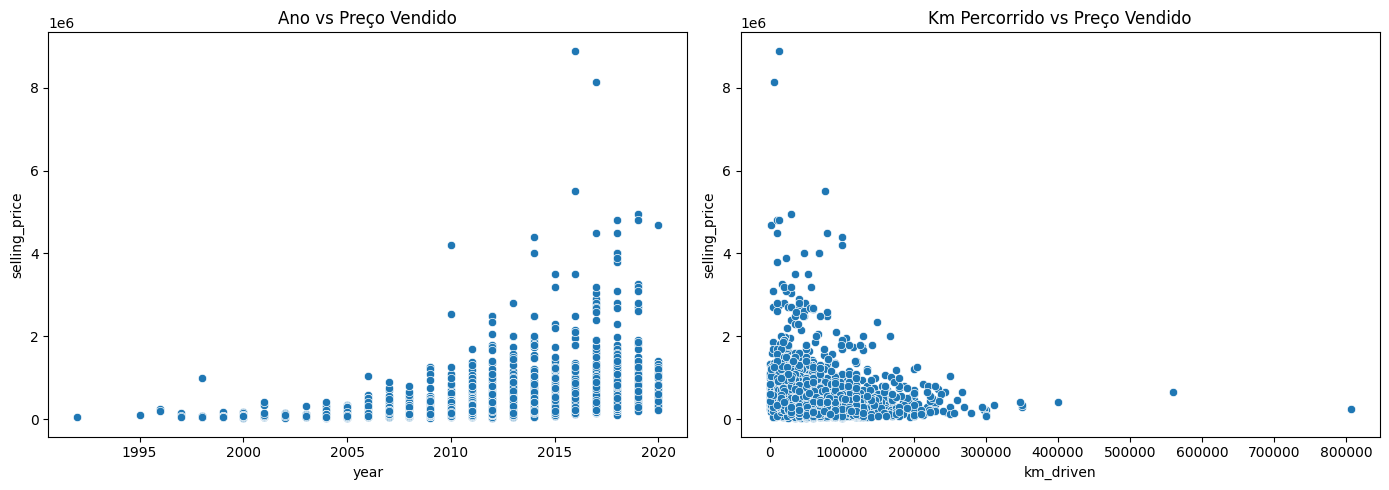

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(
    data=df,
    x='year',
    y='selling_price',
    ax=axes[0]
)
axes[0].set_title('Ano vs Preço Vendido')


sns.scatterplot(
    data=df,
    x='km_driven',
    y='selling_price',
    ax=axes[1]
)
axes[1].set_title('Km Percorrido vs Preço Vendido')

plt.tight_layout()

plt.show()

No gráfico "*Ano vs Preço Vendido*" vemos uma tendência positiva relativamente forte entre as variáveis, indicando que, o quão mais novo o carro for, maior será seu preço, como já previamente mencionado.

Já no scatterplot seguinte, podemos perceber uma leve tendência negativa entre quilometragem e preço, sugerindo que veículos menos rodados tendem a ser mais caros. Entretanto, os pontos estáo bem dispersos, indicando que a quilometragem sozinha não explica o preço dos carros.

# Insights Finais
